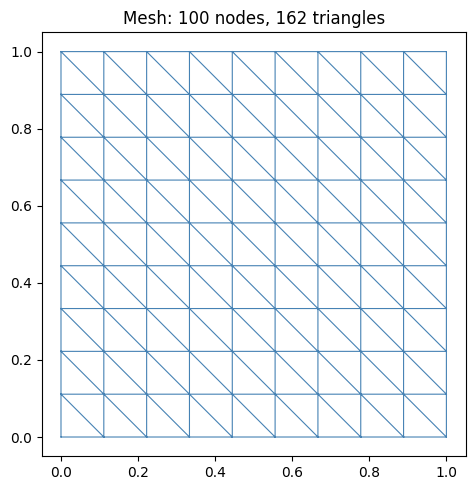

Number of nodes: 100
Number of triangles: 162
Points array shape: (100, 2)
Triangles array shape: (162, 3)

All areas equal: True
Triangle area: 0.006173
Total area: 1.000000 (should be 1.0)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make a simple grid of points on [0,1] x [0,1]
n = 10  # number of points per side
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
xx, yy = np.meshgrid(x, y)
points = np.column_stack([xx.ravel(), yy.ravel()])

# Structured triangulation — consistent diagonal direction
# node(i,j) = i*n + j  where i=row (y), j=col (x)
triangles = []
for i in range(n-1):
    for j in range(n-1):
        bl = i*n + j        # bottom left
        br = i*n + (j+1)    # bottom right
        tl = (i+1)*n + j    # top left
        tr = (i+1)*n + (j+1)# top right
        triangles.append([bl, br, tl])  # lower triangle
        triangles.append([br, tr, tl])  # upper triangle
triangles = np.array(triangles)

# Plot
fig, ax = plt.subplots(figsize=(5,5))
ax.triplot(points[:,0], points[:,1], triangles, color='steelblue', lw=0.8)
ax.set_title(f'Mesh: {len(points)} nodes, {len(triangles)} triangles')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"Number of nodes: {len(points)}")
print(f"Number of triangles: {len(triangles)}")
print(f"Points array shape: {points.shape}")
print(f"Triangles array shape: {triangles.shape}")

# Sanity check: all areas equal
from scipy.spatial import Delaunay  # keep import in case needed later
def get_shape_function_gradients(points, triangle):
    x1, y1 = points[triangle[0]]
    x2, y2 = points[triangle[1]]
    x3, y3 = points[triangle[2]]
    area = 0.5 * abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    grads = np.array([
        [y2-y3, x3-x2],
        [y3-y1, x1-x3],
        [y1-y2, x2-x1]
    ]) / (2*area)
    return grads, area

areas = [get_shape_function_gradients(points, t)[1] for t in triangles]
print(f"\nAll areas equal: {np.allclose(areas, areas[0])}")
print(f"Triangle area: {areas[0]:.6f}")
print(f"Total area: {sum(areas):.6f} (should be 1.0)")

In [2]:
def get_shape_function_gradients(points, triangle):
    """
    For a single triangle, compute the gradients of the 3 shape functions.
    These are constant vectors on the triangle.
    
    Returns:
        grads: shape (3, 2) — grads[i] = [d phi_i/dx, d phi_i/dy]
        area: scalar — area of the triangle
    """
    # Get the three vertex coordinates
    x1, y1 = points[triangle[0]]
    x2, y2 = points[triangle[1]]
    x3, y3 = points[triangle[2]]
    
    # Area of triangle (signed, so we take abs)
    area = 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))
    
    # Gradients of the three shape functions
    grads = np.array([
        [y2 - y3, x3 - x2],
        [y3 - y1, x1 - x3],
        [y1 - y2, x2 - x1]
    ]) / (2 * area)
    
    return grads, area

# Test it on the first triangle
tri0 = triangles[0]
grads, area = get_shape_function_gradients(points, tri0)

print("First triangle node indices:", tri0)
print("Node coordinates:")
for i, idx in enumerate(tri0):
    print(f"  node {i}: {points[idx]}")
print(f"\nTriangle area: {area:.6f}")
print(f"\nShape function gradients (each row = grad of one basis function):")
print(grads)

# Quick sanity check: gradients should sum to zero (partition of unity)
print(f"\nSum of gradients (should be [0,0]): {grads.sum(axis=0)}")

First triangle node indices: [ 0  1 10]
Node coordinates:
  node 0: [0. 0.]
  node 1: [0.11111111 0.        ]
  node 2: [0.         0.11111111]

Triangle area: 0.006173

Shape function gradients (each row = grad of one basis function):
[[-9. -9.]
 [ 9.  0.]
 [ 0.  9.]]

Sum of gradients (should be [0,0]): [0. 0.]


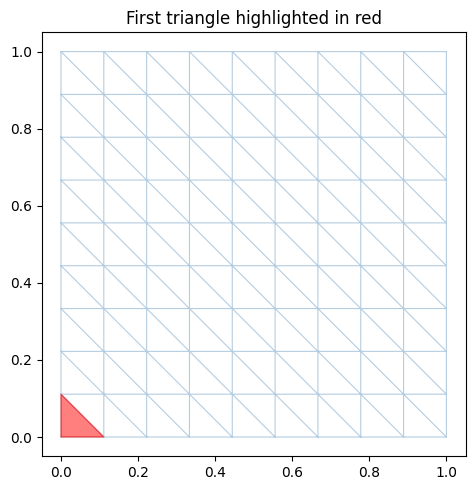

In [3]:
# Let's just visually confirm this triangle is normal sized
fig, ax = plt.subplots(figsize=(5,5))
ax.triplot(points[:,0], points[:,1], triangles, color='steelblue', lw=0.8, alpha=0.4)

# Highlight the first triangle
t = triangles[0]
triangle_coords = points[t]
triangle_patch = plt.Polygon(triangle_coords, color='red', alpha=0.5)
ax.add_patch(triangle_patch)

ax.set_title('First triangle highlighted in red')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Demo triangle index: 60
Demo triangle nodes: [33 34 43]
Node coordinates:
[[0.33333333 0.33333333]
 [0.44444444 0.33333333]
 [0.33333333 0.44444444]]


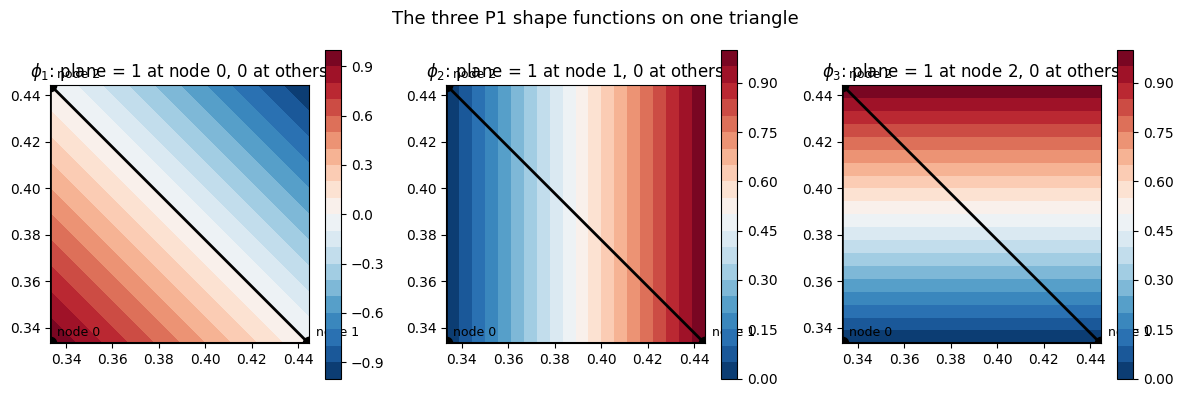


Sanity check phi_i(node_j) should be identity matrix:
  phi_1 at nodes: [1. 0. 0.]
  phi_2 at nodes: [0. 1. 0.]
  phi_3 at nodes: [0. 0. 1.]


In [4]:
def get_shape_functions(points, triangle):
    """
    Returns coefficients a, b, c for each shape function phi_i = a_i + b_i*x + c_i*y
    such that phi_i(node_j) = delta_ij
    """
    x1, y1 = points[triangle[0]]
    x2, y2 = points[triangle[1]]
    x3, y3 = points[triangle[2]]
    
    # We solve the 3x3 system [1 x y] [a,b,c]^T = e_i for each node
    A = np.array([
        [1, x1, y1],
        [1, x2, y2],
        [1, x3, y3]
    ])
    
    # Each row of coeffs gives [a_i, b_i, c_i] for shape function i
    coeffs = np.linalg.inv(A)  # columns of inv give us what we want
    # coeffs[:,i] = [a_i, b_i, c_i]
    
    return coeffs  # shape (3,3), coeffs[:,i] are coefficients for phi_i

# Evaluate on a fine grid for visualization
# Pick a nice interior triangle to visualize
# Find a triangle whose nodes are all interior (not on boundary)
for t_idx, t in enumerate(triangles):
    coords = points[t]
    if all(0.3 < coords[:,0]) and all(coords[:,0] < 0.7):
        if all(0.3 < coords[:,1]) and all(coords[:,1] < 0.7):
            demo_triangle = t
            demo_idx = t_idx
            break

print(f"Demo triangle index: {demo_idx}")
print(f"Demo triangle nodes: {demo_triangle}")
print(f"Node coordinates:\n{points[demo_triangle]}")

coeffs = get_shape_functions(points, demo_triangle)

# Evaluate each shape function on a fine grid inside the triangle
from matplotlib.tri import Triangulation

# Create fine grid just over this triangle
x_fine = np.linspace(points[demo_triangle,0].min(), points[demo_triangle,0].max(), 50)
y_fine = np.linspace(points[demo_triangle,1].min(), points[demo_triangle,1].max(), 50)
xx_fine, yy_fine = np.meshgrid(x_fine, y_fine)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    a_i, b_i, c_i = coeffs[:, i]
    phi = a_i + b_i * xx_fine + c_i * yy_fine
    
    ax = axes[i]
    im = ax.contourf(xx_fine, yy_fine, phi, levels=20, cmap='RdBu_r')
    plt.colorbar(im, ax=ax)
    
    # Draw the triangle
    tri_patch = plt.Polygon(points[demo_triangle], fill=False, 
                             edgecolor='black', linewidth=2)
    ax.add_patch(tri_patch)
    
    # Mark nodes
    ax.scatter(points[demo_triangle,0], points[demo_triangle,1], 
               color='black', zorder=5, s=80)
    for j, idx in enumerate(demo_triangle):
        ax.annotate(f'node {j}', points[idx], textcoords='offset points', 
                   xytext=(5,5), fontsize=9)
    
    ax.set_title(f'$\\phi_{i+1}$: plane = 1 at node {i}, 0 at others')
    ax.set_aspect('equal')

plt.suptitle('The three P1 shape functions on one triangle', fontsize=13)
plt.tight_layout()
plt.show()

# Sanity check: evaluate at each node
print("\nSanity check phi_i(node_j) should be identity matrix:")
for i in range(3):
    a_i, b_i, c_i = coeffs[:, i]
    vals = [a_i + b_i*points[demo_triangle[j],0] + c_i*points[demo_triangle[j],1] 
            for j in range(3)]
    print(f"  phi_{i+1} at nodes: {np.round(vals, 6)}")

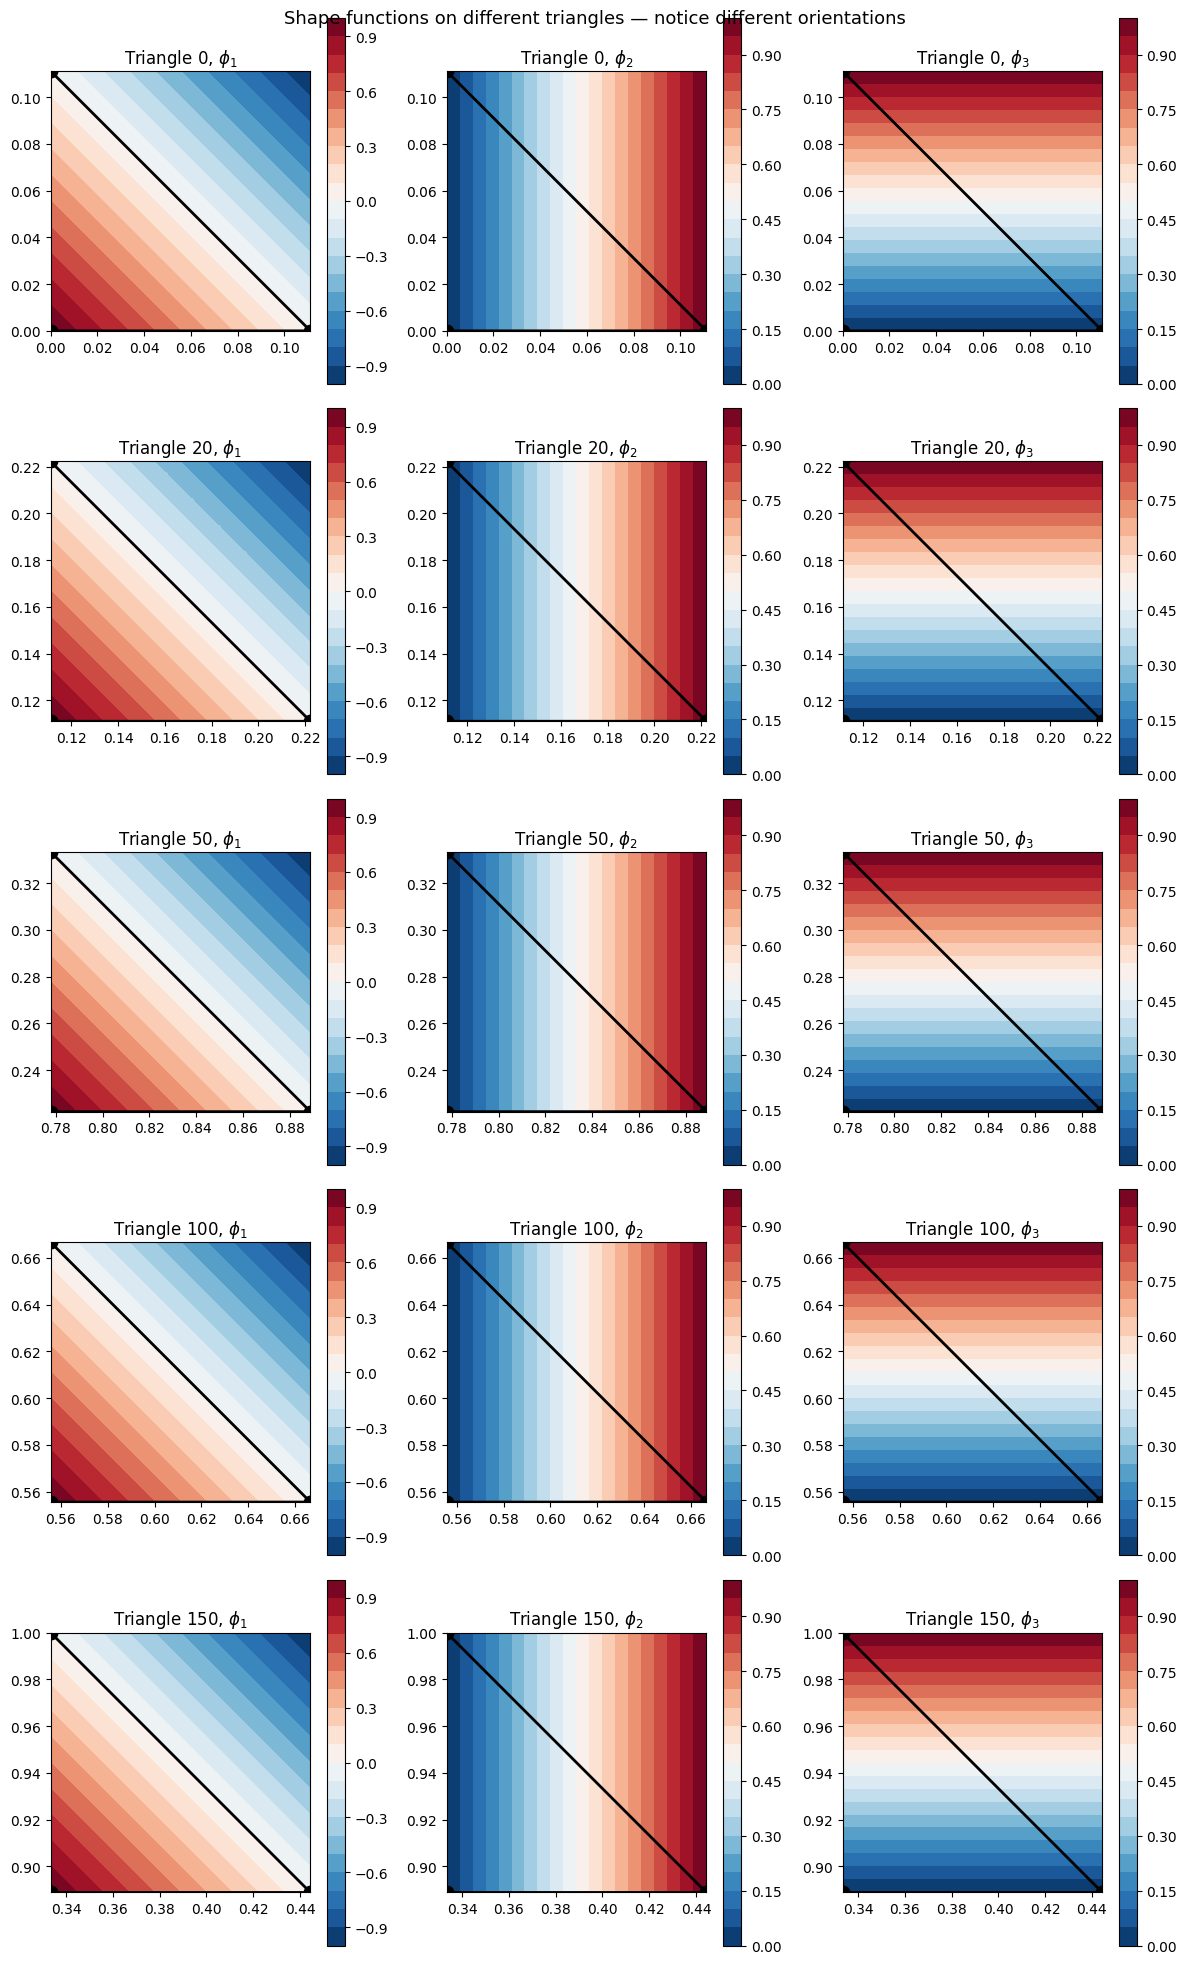

In [5]:
# Pick a few different triangles from different parts of the mesh
# and show how the shape functions look different

sample_indices = [0, 20, 50, 100, 150]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4*len(sample_indices)))

for row, t_idx in enumerate(sample_indices):
    t = triangles[t_idx]
    coords = points[t]
    coeffs = get_shape_functions(points, t)
    
    x_fine = np.linspace(coords[:,0].min(), coords[:,0].max(), 50)
    y_fine = np.linspace(coords[:,1].min(), coords[:,1].max(), 50)
    xx_fine, yy_fine = np.meshgrid(x_fine, y_fine)
    
    for i in range(3):
        a_i, b_i, c_i = coeffs[:, i]
        phi = a_i + b_i * xx_fine + c_i * yy_fine
        
        ax = axes[row, i]
        im = ax.contourf(xx_fine, yy_fine, phi, levels=20, cmap='RdBu_r')
        plt.colorbar(im, ax=ax)
        
        tri_patch = plt.Polygon(coords, fill=False, edgecolor='black', linewidth=2)
        ax.add_patch(tri_patch)
        ax.scatter(coords[:,0], coords[:,1], color='black', zorder=5, s=80)
        
        ax.set_title(f'Triangle {t_idx}, $\\phi_{i+1}$')
        ax.set_aspect('equal')

plt.suptitle('Shape functions on different triangles — notice different orientations', 
             fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
def build_B_matrix(grads):
    """
    Build the 3x6 strain-displacement matrix B for:
    
    e = [epsilon_11, epsilon_22, epsilon_12]^T
    
    grads: shape (3,2) where grads[i] = [b_i, c_i]
           b_i = d phi_i / dx
           c_i = d phi_i / dy
    
    B =
    [ b1    0     b2    0     b3    0  ]
    [ 0     c1    0     c2    0     c3 ]
    [ c1/2  b1/2  c2/2  b2/2  c3/2  b3/2 ]
    """

    B = np.zeros((3, 6))

    for i in range(3):
        b_i = grads[i, 0]  # d phi_i / dx
        c_i = grads[i, 1]  # d phi_i / dy

        # epsilon_11 = du_x/dx
        B[0, 2*i] = b_i

        # epsilon_22 = du_y/dy
        B[1, 2*i+1] = c_i

        # epsilon_12 = 1/2(du_x/dy + du_y/dx)
        B[2, 2*i] = c_i / 2
        B[2, 2*i+1] = b_i / 2

    return B

def build_C_matrix(mu, lam):
    """
    Build the 3x3 material matrix C.
    """
    C = np.array([
        [lam + 2*mu,  lam,        0    ],
        [lam,         lam + 2*mu, 0    ],
        [0,           0,          4*mu ]
    ])
    return C

def local_stiffness(points, triangle, mu, lam):
    """
    Compute 6x6 local stiffness matrix for one triangle.
    """
    grads, area = get_shape_function_gradients(points, triangle)
    B = build_B_matrix(grads)
    C = build_C_matrix(mu, lam)
    K_local = area * (B.T @ C @ B)
    return K_local

# --- Verification ---
mu  = 1.0
lam = 1.0

K_loc = local_stiffness(points, triangles[0], mu, lam)
print("Local stiffness matrix shape:", K_loc.shape)
print("\nLocal stiffness matrix:")
print(np.round(K_loc, 4))

# Sanity check 1: K should be symmetric
print("\nIs symmetric?", np.allclose(K_loc, K_loc.T))

# Sanity check 2: applying uniform translation [1,0,1,0,1,0] 
# should give zero force (rigid body motion = no strain)
U_translate_x = np.array([1, 0, 1, 0, 1, 0])  # all nodes move right by 1
U_translate_y = np.array([0, 1, 0, 1, 0, 1])  # all nodes move up by 1
print("\nK @ uniform x-translation (should be ~0):", 
      np.round(K_loc @ U_translate_x, 10))
print("K @ uniform y-translation (should be ~0):", 
      np.round(K_loc @ U_translate_y, 10))

U_rotate = np.array([
    -points[triangles[0][0],1], points[triangles[0][0],0],
    -points[triangles[0][1],1], points[triangles[0][1],0],
    -points[triangles[0][2],1], points[triangles[0][2],0]
])

print(np.round(K_loc @ U_rotate, 10))

Local stiffness matrix shape: (6, 6)

Local stiffness matrix:
[[ 2.   1.  -1.5 -0.5 -0.5 -0.5]
 [ 1.   2.  -0.5 -0.5 -0.5 -1.5]
 [-1.5 -0.5  1.5  0.   0.   0.5]
 [-0.5 -0.5  0.   0.5  0.5  0. ]
 [-0.5 -0.5  0.   0.5  0.5  0. ]
 [-0.5 -1.5  0.5  0.   0.   1.5]]

Is symmetric? True

K @ uniform x-translation (should be ~0): [0. 0. 0. 0. 0. 0.]
K @ uniform y-translation (should be ~0): [0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0.]


In [7]:
from scipy.sparse import coo_matrix, csr_matrix

def assemble_global_stiffness(pts, tris, mu, lam):
    """
    Vectorized assembly of global stiffness matrix K of size (2N x 2N).
    Replaces the original loop-based version with the same interface.
    """
    N       = len(pts)
    n_tris  = len(tris)

    # All triangle coordinates at once — shape (n_tris, 3, 2)
    coords = pts[tris]
    x1, y1 = coords[:,0,0], coords[:,0,1]
    x2, y2 = coords[:,1,0], coords[:,1,1]
    x3, y3 = coords[:,2,0], coords[:,2,1]

    # Areas — shape (n_tris,)
    areas = 0.5 * np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

    # Shape function gradients — shape (n_tris, 3, 2)
    grads = np.zeros((n_tris, 3, 2))
    grads[:,0,0] = (y2-y3) / (2*areas);  grads[:,0,1] = (x3-x2) / (2*areas)
    grads[:,1,0] = (y3-y1) / (2*areas);  grads[:,1,1] = (x1-x3) / (2*areas)
    grads[:,2,0] = (y1-y2) / (2*areas);  grads[:,2,1] = (x2-x1) / (2*areas)

    B = np.array([build_B_matrix(grads[t]) for t in range(n_tris)])  # (n_tris, 3, 6)
    C = build_C_matrix(mu, lam)                                        # (3, 3)

    # Local stiffness matrices — shape (n_tris, 6, 6)
    BtC      = np.einsum('tji,jk->tik', B, C)          # (n_tris, 6, 3)
    K_loc    = np.einsum('tij,tjk,t->tik', BtC, B, areas)  # (n_tris, 6, 6)

    # Global DOF indices — shape (n_tris, 6)
    dofs = np.zeros((n_tris, 6), dtype=int)
    for i in range(3):
        dofs[:,2*i]   = 2*tris[:,i]
        dofs[:,2*i+1] = 2*tris[:,i] + 1

    # COO assembly — duplicate (i,j) entries are summed automatically
    row_idx = np.broadcast_to(dofs[:,:,None], (n_tris, 6, 6)).reshape(-1)
    col_idx = np.broadcast_to(dofs[:,None,:], (n_tris, 6, 6)).reshape(-1)

    return coo_matrix((K_loc.reshape(-1), (row_idx, col_idx)),
                      shape=(2*N, 2*N)).tocsr()

In [8]:
mu, lam = 1.0, 1.0
K_global = assemble_global_stiffness(points, triangles, mu, lam)
N = len(points)

print(f"Shape: {K_global.shape}, nnz: {K_global.nnz}")
print(f"Symmetric: {np.allclose(K_global.toarray(), K_global.toarray().T)}")

U_x = np.zeros(2*N); U_x[0::2] = 1.0
U_y = np.zeros(2*N); U_y[1::2] = 1.0
print(f"K @ x-translation max: {np.max(np.abs(K_global @ U_x)):.2e}")
print(f"K @ y-translation max: {np.max(np.abs(K_global @ U_y)):.2e}")

print(K_global[3,3])

Shape: (200, 200), nnz: 2488
Symmetric: True
K @ x-translation max: 1.67e-15
K @ y-translation max: 1.78e-15
4.0


In [9]:
def identify_boundary_nodes(points, tol=1e-12):
    """
    Identify nodes on each part of the boundary of [0,1]x[0,1].
    Returns dictionaries of node indices for each boundary segment.
    """
    x, y = points[:, 0], points[:, 1]
    
    boundary_nodes = {
        'left':   np.where(x < tol)[0],        # x = 0, Dirichlet
        'top':    np.where(y > 1 - tol)[0],    # y = 1, Dirichlet
        'right':  np.where(x > 1 - tol)[0],    # x = 1, Neumann
        'bottom': np.where(y < tol)[0],         # y = 0, Neumann
    }
    return boundary_nodes

boundary_nodes = identify_boundary_nodes(points)
for name, nodes in boundary_nodes.items():
    print(f"{name}: {len(nodes)} nodes, indices: {nodes[:5]}...")

left: 10 nodes, indices: [ 0 10 20 30 40]...
top: 10 nodes, indices: [90 91 92 93 94]...
right: 10 nodes, indices: [ 9 19 29 39 49]...
bottom: 10 nodes, indices: [0 1 2 3 4]...


In [10]:
def body_force(x, y):
    """
    Body force f(x,y) — gravity pulling beam downward.
    Returns a 2-vector [f1, f2].
    """
    f1 = 0.0    # no horizontal body force
    f2 = -1.0   # gravity downward
    return np.array([f1, f2])

def neumann_traction(x, y, boundary):
    """
    Traction on Neumann boundaries (right, top, bottom).
    Cantilever beam: all free surfaces have zero traction.
    Returns a 2-vector [t1, t2].
    """
    if boundary == 'right':
        return np.array([0.0, 0.0])   # free end — no traction
    elif boundary == 'bottom':
        return np.array([0.0, 0.0])   # free surface — no traction
    elif boundary == 'top':
        return np.array([0.0, 0.0])   # free surface — no traction

def dirichlet_displacement(x, y, boundary):
    """
    Prescribed displacement on Dirichlet boundary (left only).
    Cantilever beam: left edge clamped to wall — zero displacement.
    Returns a 2-vector [g1, g2].
    """
    if boundary == 'left':
        return np.array([0.0, 0.0])   # clamped — no movement

In [11]:
qp = np.array([
    [0.108103018168070, 0.445948490915965],
    [0.445948490915965, 0.108103018168070],
    [0.445948490915965, 0.445948490915965],
    [0.816847572980459, 0.091576213509771],
    [0.091576213509771, 0.816847213509771],
    [0.091576213509771, 0.091576213509771]
])

qw = np.array([
    0.223381589678011,
    0.223381589678011,
    0.223381589678011,
    0.109951743655322,
    0.109951743655322,
    0.109951743655322
])

edge_qp = np.array([
    (1-1/np.sqrt(3))/2,
    (1+1/np.sqrt(3))/2
])

edge_qw = np.array([1,1])

In [12]:
def assemble_force_vector(pts, tris, boundary_nodes):
    """
    Vectorized FEM force assembly:
    F = integral(phi*f)dA + integral(phi*t)ds
    """

    N = len(pts)
    F = np.zeros(2*N)

    coords = pts[tris]
    x1,y1 = coords[:,0,0], coords[:,0,1]
    x2,y2 = coords[:,1,0], coords[:,1,1]
    x3,y3 = coords[:,2,0], coords[:,2,1]

    areas = 0.5*np.abs((x2-x1)*(y3-y1)-(x3-x1)*(y2-y1))

    # ---- body force ----
    for (xi,eta),w in zip(qp,qw):
        px = x1+(x2-x1)*xi+(x3-x1)*eta
        py = y1+(y2-y1)*xi+(y3-y1)*eta

        phi = np.array([1-xi-eta, xi, eta])
        f = body_force(px,py)

        for k in range(3):
            nodes = tris[:,k]
            weight = areas*w*phi[k]

            np.add.at(F,2*nodes,weight*f[0])
            np.add.at(F,2*nodes+1,weight*f[1])


    # ---- Neumann traction ----
    for bname in ['right','top','bottom']:
        nodes = boundary_nodes[bname]

        if bname in ['right','left']: nodes = nodes[np.argsort(pts[nodes,1])]
        else: nodes = nodes[np.argsort(pts[nodes,0])]

        n1, n2 = nodes[:-1], nodes[1:]

        p1, p2 = pts[n1], pts[n2]

        length = np.linalg.norm(p2-p1,axis=1)


        for s,w in zip(edge_qp, edge_qw):

            px = p1[:,0]+s*(p2[:,0]-p1[:,0])
            py = p1[:,1]+s*(p2[:,1]-p1[:,1])

            t = neumann_traction(px,py,bname)

            weight = length/2*w

            np.add.at(F,2*n1,weight*t[0]*(1-s))
            np.add.at(F,2*n1+1,weight*t[1]*(1-s))

            np.add.at(F,2*n2,weight*t[0]*s)
            np.add.at(F,2*n2+1,weight*t[1]*s)

    return F

shape: (200,)
Fx: 0.0
Fy: -0.9999999999999994


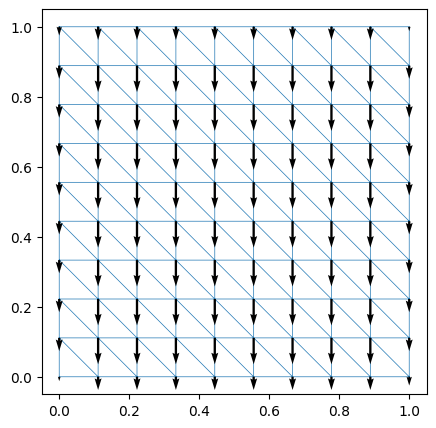

In [13]:
n=10
x=y=np.linspace(0,1,n)
xx,yy=np.meshgrid(x,y)
points=np.column_stack([xx.ravel(),yy.ravel()])

tris=[]
for i in range(n-1):
    for j in range(n-1):
        bl=i*n+j; br=bl+1; tl=bl+n; tr=tl+1
        tris+=[[bl,br,tl],[br,tr,tl]]

tris=np.array(tris)
boundary_nodes=identify_boundary_nodes(points)

F=assemble_force_vector(points,tris,boundary_nodes)

print("shape:",F.shape)
print("Fx:",F[0::2].sum())
print("Fy:",F[1::2].sum())

import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(5,5))
ax.triplot(points[:,0],points[:,1],tris,lw=0.5)
ax.quiver(points[:,0],points[:,1],F[0::2],F[1::2])
ax.set_aspect('equal')
plt.show()

Solution vector shape: (200,)


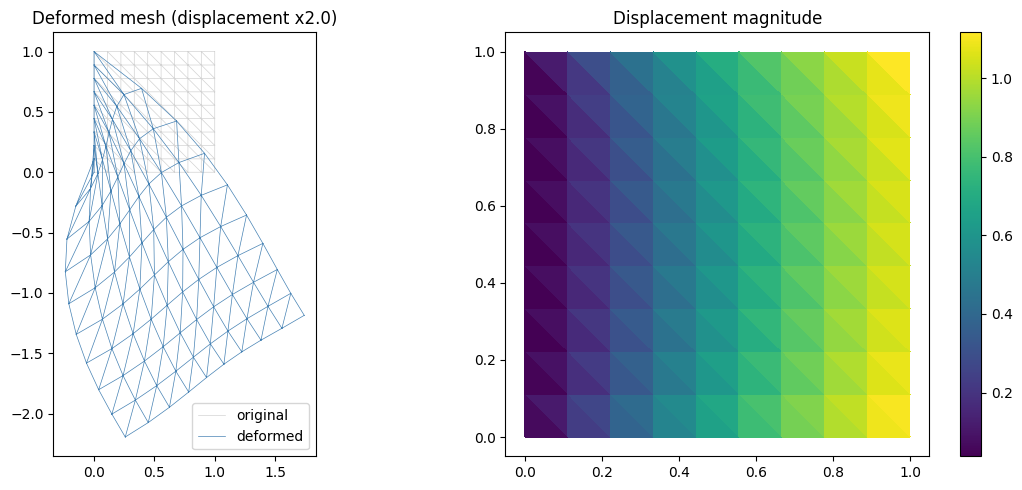

In [14]:
from scipy.linalg import solve

def apply_dirichlet_and_solve(K_global, F, points, boundary_nodes):
    """
    Apply Dirichlet boundary conditions and solve KU = F.
    
    Strategy: penalty method replacement.
    For each Dirichlet dof i with prescribed value g:
        - Set K[i,i] = large number
        - Set F[i] = large number * g
    This effectively forces U[i] = g without removing rows/cols.
    """
    N = len(points)
    
    # Work with dense copy for modification
    K = K_global.toarray().copy()
    F = F.copy()
    
    dirichlet_boundaries = ['left']
    
    for bname in dirichlet_boundaries:
        bnodes = boundary_nodes[bname]
        for node in bnodes:
            g = dirichlet_displacement(points[node, 0], points[node, 1], bname)
            
            # Horizontal dof
            dof_x = 2*node
            K[dof_x, :] = 0.0
            K[:, dof_x] = 0.0
            K[dof_x, dof_x] = 1.0
            F[dof_x] = g[0]
            
            # Vertical dof
            dof_y = 2*node + 1
            K[dof_y, :] = 0.0
            K[:, dof_y] = 0.0
            K[dof_y, dof_y] = 1.0
            F[dof_y] = g[1]
    
    # Solve the linear system
    U = solve(K, F)
    
    return U

# --- Solve ---
mu  = 1.0
lam = 1.0

K_global = assemble_global_stiffness(points, triangles, mu, lam)
F = assemble_force_vector(points, triangles, boundary_nodes)
U = apply_dirichlet_and_solve(K_global, F, points, boundary_nodes)

print(f"Solution vector shape: {U.shape}")

# Check Dirichlet nodes are actually zero
left_nodes = boundary_nodes['left']
top_nodes  = boundary_nodes['top']

# Visualize displacement
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Deformed mesh
scale = 2.0  # exaggerate displacement for visibility
deformed = points.copy()
deformed[:, 0] += scale * U[0::2]
deformed[:, 1] += scale * U[1::2]

axes[0].triplot(points[:, 0], points[:, 1], triangles, 
                color='lightgray', lw=0.5, label='original')
axes[0].triplot(deformed[:, 0], deformed[:, 1], triangles, 
                color='steelblue', lw=0.5, label='deformed')
axes[0].set_title(f'Deformed mesh (displacement x{scale})')
axes[0].set_aspect('equal')
axes[0].legend()

# Displacement magnitude
mag = np.sqrt(U[0::2]**2 + U[1::2]**2)
tpc = axes[1].tripcolor(points[:,0], points[:,1], triangles, mag, cmap='viridis')
plt.colorbar(tpc, ax=axes[1])
axes[1].set_title('Displacement magnitude')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Global displacement range: [0.0000, 1.1582]


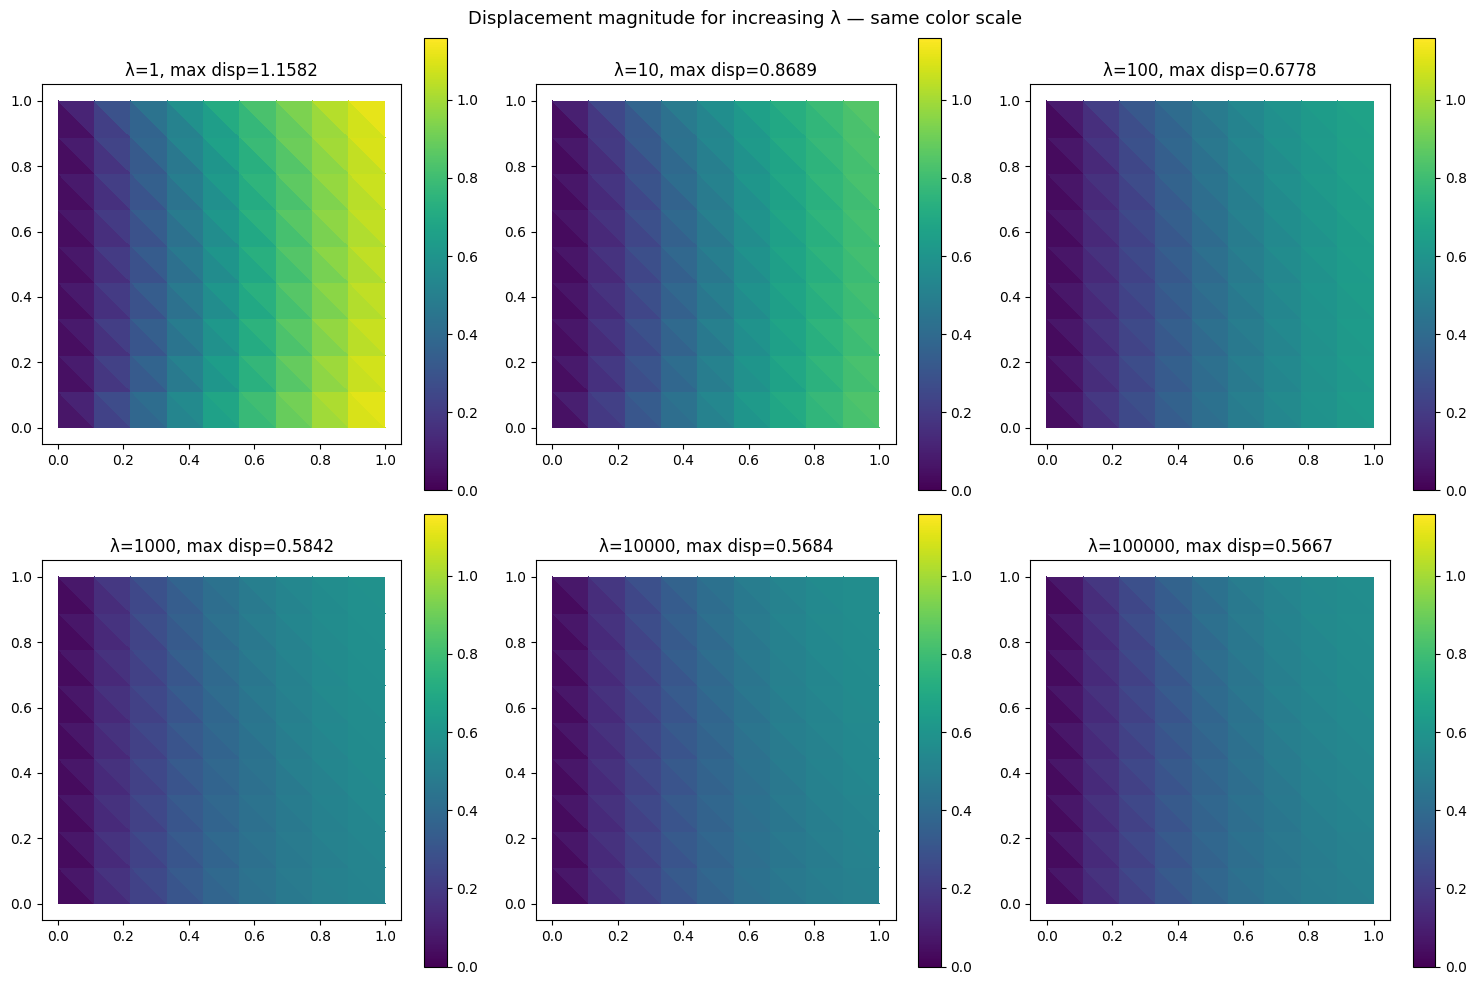


    lambda     max displacement    ratio to lambda=1
         1             1.158209             1.000000
        10             0.868923             0.750230
       100             0.677850             0.585257
      1000             0.584191             0.504392
     10000             0.568438             0.490791
    100000             0.566743             0.489327


In [15]:
lambda_values = [1, 10, 100, 1000, 10000, 100000]
mu = 1.0

solutions = {}

# First pass: compute all solutions and find global min/max
for lam in lambda_values:
    K_global = assemble_global_stiffness(points, tris, mu, lam)
    F = assemble_force_vector(points, tris, boundary_nodes)
    U = apply_dirichlet_and_solve(K_global, F, points, boundary_nodes)
    solutions[lam] = U

# Global color scale
all_mags = [np.sqrt(solutions[lam][0::2]**2 + solutions[lam][1::2]**2) 
            for lam in lambda_values]
vmin = 0.0
vmax = max(m.max() for m in all_mags)
print(f"Global displacement range: [{vmin:.4f}, {vmax:.4f}]")

# Second pass: plot with fixed scale
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, lam in enumerate(lambda_values):
    mag = all_mags[idx]
    ax = axes[idx]
    tpc = ax.tripcolor(points[:,0], points[:,1], tris, mag,
                       cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(tpc, ax=ax)
    ax.set_title(f'λ={lam}, max disp={mag.max():.4f}')
    ax.set_aspect('equal')

plt.suptitle('Displacement magnitude for increasing λ — same color scale', 
             fontsize=13)
plt.tight_layout()
plt.show()

# Print table
print(f"\n{'lambda':>10} {'max displacement':>20} {'ratio to lambda=1':>20}")
base = all_mags[0].max()
for lam, mag in zip(lambda_values, all_mags):
    print(f"{lam:>10} {mag.max():>20.6f} {mag.max()/base:>20.6f}")

In [16]:
import numpy as np
from scipy.sparse.linalg import spsolve

pi = np.pi

def build_mesh(n):
    x = y = np.linspace(0, 1, n)
    xx, yy = np.meshgrid(x, y)
    pts = np.column_stack([xx.ravel(), yy.ravel()])
    tris = []
    for i in range(n-1):
        for j in range(n-1):
            bl = i*n+j; br = bl+1; tl = bl+n; tr = tl+1
            tris += [[bl, br, tl], [br, tr, tl]]
    return pts, np.array(tris)

def u_exact(pts):
    x, y = pts[:,0], pts[:,1]
    U = np.zeros(2*len(pts))
    U[0::2] = np.sin(pi*x) * np.sin(pi*y)
    U[1::2] = np.cos(pi*x) * np.sin(pi*y)
    return U

def compute_L2_error(pts, tris, U):
    Ue  = u_exact(pts)
    err = U - Ue
    ex  = err[0::2]
    ey  = err[1::2]

    coords = pts[tris]
    x1,y1  = coords[:,0,0], coords[:,0,1]
    x2,y2  = coords[:,1,0], coords[:,1,1]
    x3,y3  = coords[:,2,0], coords[:,2,1]
    areas  = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

    err2 = 0.0
    for (xi, eta), w in zip(qp, qw):
        phi  = np.array([1-xi-eta, xi, eta])
        ex_q = sum(phi[k]*ex[tris[:,k]] for k in range(3))
        ey_q = sum(phi[k]*ey[tris[:,k]] for k in range(3))
        err2 += np.sum(areas * w * (ex_q**2 + ey_q**2))

    return np.sqrt(err2)

In [17]:
# ── Manufactured body force: f = -div σ(u_exact) ──────────────────────────
# u_exact = [sin(πx)sin(πy), cos(πx)sin(πy)]
#
# ε₁₁ = π cos(πx)sin(πy)
# ε₂₂ = π cos(πx)cos(πy)
# ε₁₂ = ½π sin(πx)(cos(πy) − sin(πy))
#
# σ₁₁ = (2μ+λ)ε₁₁ + λε₂₂
# σ₂₂ = λε₁₁    + (2μ+λ)ε₂₂
# σ₁₂ = 2μ ε₁₂
#
# f₁ = −(∂σ₁₁/∂x + ∂σ₁₂/∂y) = π²sin(πx)[(3μ+λ)sin(πy) + (μ+λ)cos(πy)]
# f₂ = −(∂σ₁₂/∂x + ∂σ₂₂/∂y) = π²cos(πx)[(3μ+λ)sin(πy) − (μ+λ)cos(πy)]

def f_manufactured(pts, mu, lam):
    x, y = pts[:,0], pts[:,1]
    pi2  = np.pi**2
    f    = np.zeros_like(pts)
    f[:,0] = pi2*np.sin(np.pi*x)*((3*mu+lam)*np.sin(np.pi*y) + (mu+lam)*np.cos(np.pi*y))
    f[:,1] = pi2*np.cos(np.pi*x)*((3*mu+lam)*np.sin(np.pi*y) - (mu+lam)*np.cos(np.pi*y))
    return f

# ── Load vector assembled from body force (not K @ Ue) ─────────────────────
def assemble_load_vector_mms(pts, tris, mu, lam):
    """F_i = ∫ φ_i · f dΩ  using quadrature points from cell 10."""
    N          = len(pts)
    F          = np.zeros(2*N)
    f_at_nodes = f_manufactured(pts, mu, lam)   # (N, 2)

    coords = pts[tris]
    x1,y1  = coords[:,0,0], coords[:,0,1]
    x2,y2  = coords[:,1,0], coords[:,1,1]
    x3,y3  = coords[:,2,0], coords[:,2,1]
    areas  = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

    for (xi, eta), w in zip(qp, qw):
        phi  = np.array([1-xi-eta, xi, eta])
        fx_q = sum(phi[k]*f_at_nodes[tris[:,k], 0] for k in range(3))
        fy_q = sum(phi[k]*f_at_nodes[tris[:,k], 1] for k in range(3))
        for k in range(3):
            wt = areas * w * phi[k]
            np.add.at(F, 2*tris[:,k],   wt * fx_q)
            np.add.at(F, 2*tris[:,k]+1, wt * fy_q)
    return F

# ── Dirichlet BCs from u_exact on boundary nodes only ──────────────────────
def apply_dirichlet_and_solve_mms(K, F, pts):
    """Pin all 4 edges to u_exact values, solve."""
    tol    = 1e-12
    is_bnd = ((pts[:,0] < tol) | (pts[:,0] > 1-tol) |
              (pts[:,1] < tol) | (pts[:,1] > 1-tol))

    u_bc = u_exact(pts)   # exact at all nodes; we index only boundary ones
    K    = K.tolil(copy=True)
    F    = F.copy()

    for i in np.where(is_bnd)[0]:
        for d in range(2):
            dof           = 2*i + d
            K.rows[dof]   = [dof]
            K.data[dof]   = [1.0]
            F[dof]        = u_bc[2*i + d]

    return spsolve(K.tocsr(), F)

# ── Convergence study ───────────────────────────────────────────────────────
lambda_values = [1, 10, 100, 1000, 10000]
mesh_sizes    = [4, 8, 16, 32, 64, 128, 256]
mu            = 1.0
results       = {}

for lam in lambda_values:
    for n in mesh_sizes:
        pts, tris = build_mesh(n)

        K   = assemble_global_stiffness(pts, tris, mu, lam)
        F   = assemble_load_vector_mms(pts, tris, mu, lam)   # ← body force, not K@Ue
        U   = apply_dirichlet_and_solve_mms(K, F, pts)       # ← boundary only

        err              = compute_L2_error(pts, tris, U)
        results[(lam,n)] = err
        print(f"λ={lam:>6}, n={n:>3}, L2 error={err:.3e}")

λ=     1, n=  4, L2 error=9.796e-02
λ=     1, n=  8, L2 error=2.730e-02
λ=     1, n= 16, L2 error=6.563e-03
λ=     1, n= 32, L2 error=1.573e-03
λ=     1, n= 64, L2 error=3.831e-04
λ=     1, n=128, L2 error=9.441e-05
λ=     1, n=256, L2 error=2.343e-05
λ=    10, n=  4, L2 error=1.011e-01
λ=    10, n=  8, L2 error=3.571e-02
λ=    10, n= 16, L2 error=1.020e-02
λ=    10, n= 32, L2 error=2.609e-03
λ=    10, n= 64, L2 error=6.472e-04
λ=    10, n=128, L2 error=1.602e-04
λ=    10, n=256, L2 error=3.980e-05
λ=   100, n=  4, L2 error=1.053e-01
λ=   100, n=  8, L2 error=6.381e-02
λ=   100, n= 16, L2 error=3.455e-02
λ=   100, n= 32, L2 error=1.283e-02
λ=   100, n= 64, L2 error=3.712e-03
λ=   100, n=128, L2 error=9.646e-04
λ=   100, n=256, L2 error=2.428e-04
λ=  1000, n=  4, L2 error=1.062e-01
λ=  1000, n=  8, L2 error=8.024e-02
λ=  1000, n= 16, L2 error=7.207e-02
λ=  1000, n= 32, L2 error=5.018e-02
λ=  1000, n= 64, L2 error=2.382e-02
λ=  1000, n=128, L2 error=8.045e-03
λ=  1000, n=256, L2 error=2.

In [18]:
# ── Energy norm error ───────────────────────────────────────────────────────
def compute_energy_error(pts, tris, U, mu, lam):
    """
    Energy norm: sqrt(a(e,e)) where e = U - U_exact
    a(e,e) = ∫ 2μ ε(e):ε(e) + λ div(e) div(e) dx
    Strain is piecewise constant for P1, so no quadrature needed.
    """
    Ue  = u_exact(pts)
    err = U - Ue
    ex  = err[0::2]
    ey  = err[1::2]

    coords = pts[tris]
    x1,y1  = coords[:,0,0], coords[:,0,1]
    x2,y2  = coords[:,1,0], coords[:,1,1]
    x3,y3  = coords[:,2,0], coords[:,2,1]
    areas  = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

    # Gradients for all triangles at once
    grads = np.zeros((len(tris), 3, 2))
    grads[:,0,0] = (y2-y3)/(2*areas); grads[:,0,1] = (x3-x2)/(2*areas)
    grads[:,1,0] = (y3-y1)/(2*areas); grads[:,1,1] = (x1-x3)/(2*areas)
    grads[:,2,0] = (y1-y2)/(2*areas); grads[:,2,1] = (x2-x1)/(2*areas)

    # Error at nodes for each triangle — shape (n_tris, 3)
    ex_loc = ex[tris]
    ey_loc = ey[tris]

    # Strain components (constant per element)
    eps11 = np.einsum('ti,ti->t', grads[:,:,0], ex_loc)
    eps22 = np.einsum('ti,ti->t', grads[:,:,1], ey_loc)
    eps12 = 0.5*(np.einsum('ti,ti->t', grads[:,:,1], ex_loc) +
                 np.einsum('ti,ti->t', grads[:,:,0], ey_loc))
    div_e = eps11 + eps22

    energy = np.sum(areas * (2*mu*(eps11**2 + 2*eps12**2 + eps22**2) + lam*div_e**2))
    return np.sqrt(energy)


# ── Rerun convergence collecting both errors ────────────────────────────────
lambda_values = [1, 10, 100, 1000, 10000]
mesh_sizes    = [4, 8, 16, 32, 64, 128, 256]
mu            = 1.0

results_L2     = {}
results_energy = {}

for lam in lambda_values:
    for n in mesh_sizes:
        pts, tris = build_mesh(n)
        K = assemble_global_stiffness(pts, tris, mu, lam)
        F = assemble_load_vector_mms(pts, tris, mu, lam)
        U = apply_dirichlet_and_solve_mms(K, F, pts)

        results_L2[(lam,n)]     = compute_L2_error(pts, tris, U)
        results_energy[(lam,n)] = compute_energy_error(pts, tris, U, mu, lam)

        print(f"λ={lam:>6}, n={n:>3}  "
              f"L2={results_L2[(lam,n)]:.2e}  "
              f"energy={results_energy[(lam,n)]:.2e}")

λ=     1, n=  4  L2=9.80e-02  energy=7.66e-01
λ=     1, n=  8  L2=2.73e-02  energy=1.93e-01
λ=     1, n= 16  L2=6.56e-03  energy=4.50e-02


λ=     1, n= 32  L2=1.57e-03  energy=1.07e-02
λ=     1, n= 64  L2=3.83e-04  energy=2.60e-03
λ=     1, n=128  L2=9.44e-05  energy=6.40e-04
λ=     1, n=256  L2=2.34e-05  energy=1.59e-04
λ=    10, n=  4  L2=1.01e-01  energy=1.44e+00
λ=    10, n=  8  L2=3.57e-02  energy=3.98e-01
λ=    10, n= 16  L2=1.02e-02  energy=9.89e-02
λ=    10, n= 32  L2=2.61e-03  energy=2.41e-02
λ=    10, n= 64  L2=6.47e-04  energy=5.90e-03
λ=    10, n=128  L2=1.60e-04  energy=1.46e-03
λ=    10, n=256  L2=3.98e-05  energy=3.61e-04
λ=   100, n=  4  L2=1.05e-01  energy=4.15e+00
λ=   100, n=  8  L2=6.38e-02  energy=1.34e+00
λ=   100, n= 16  L2=3.45e-02  energy=4.24e-01
λ=   100, n= 32  L2=1.28e-02  energy=1.23e-01
λ=   100, n= 64  L2=3.71e-03  energy=3.25e-02
λ=   100, n=128  L2=9.65e-04  energy=8.21e-03
λ=   100, n=256  L2=2.43e-04  energy=2.05e-03
λ=  1000, n=  4  L2=1.06e-01  energy=1.30e+01
λ=  1000, n=  8  L2=8.02e-02  energy=4.43e+00
λ=  1000, n= 16  L2=7.21e-02  energy=1.72e+00
λ=  1000, n= 32  L2=5.02e-02  ener

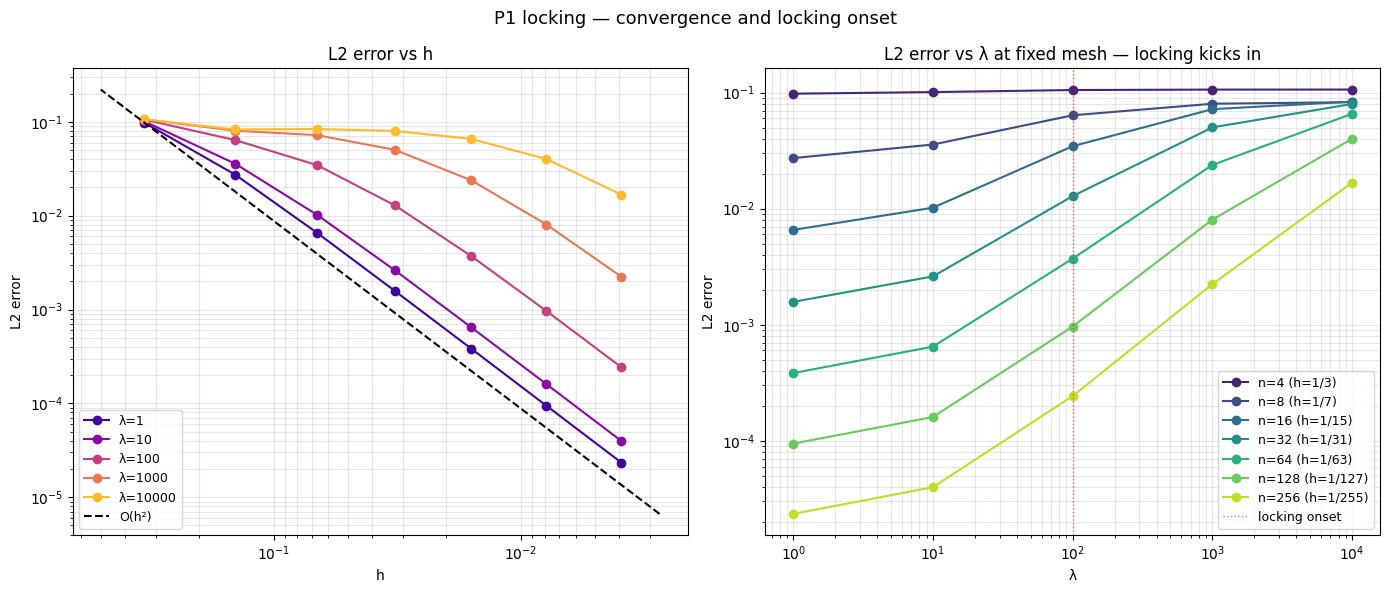

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(lambda_values)))
hs     = [1/(n-1) for n in mesh_sizes]
h_ref  = np.array([min(hs)*0.7, max(hs)*1.5])

# Left: convergence vs h (same as before)
for idx, lam in enumerate(lambda_values):
    L2s = [results_L2[(lam, n)] for n in mesh_sizes]
    axes[0].loglog(hs, L2s, 'o-', color=colors[idx], label=f'λ={lam}')

h0   = 1/(mesh_sizes[0]-1)
C_L2 = results_L2[(1, mesh_sizes[0])] / h0**2
axes[0].loglog(h_ref, C_L2 * h_ref**2, 'k--', lw=1.5, label='O(h²)')
axes[0].set_xlabel('h');  axes[0].invert_xaxis()
axes[0].set_ylabel('L2 error')
axes[0].set_title('L2 error vs h')

# Right: error vs λ at fixed mesh sizes — the locking plot
colors2 = plt.cm.viridis(np.linspace(0.1, 0.9, len(mesh_sizes)))
for idx, n in enumerate(mesh_sizes):
    errs = [results_L2[(lam, n)] for lam in lambda_values]
    axes[1].loglog(lambda_values, errs, 'o-', color=colors2[idx], label=f'n={n} (h=1/{n-1})')

axes[1].set_xlabel('λ')
axes[1].set_ylabel('L2 error')
axes[1].set_title('L2 error vs λ at fixed mesh — locking kicks in')
axes[1].legend(fontsize=9)

# Mark the locking threshold roughly
axes[1].axvline(x=100, color='red', lw=1, linestyle=':', alpha=0.6, label='locking onset')

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('P1 locking — convergence and locking onset', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
def build_p2_mesh(pts, tris):
    N = len(pts)
    edge_to_mid = {}
    mids = []
    tris2 = np.zeros((len(tris), 6), dtype=int)

    for t, (v0, v1, v2) in enumerate(tris):
        tris2[t, 0:3] = [v0, v1, v2]
        # local 3,4,5 = midpoint opposite v0, v1, v2 respectively
        for local_idx, (a, b) in enumerate([(v1, v2), (v2, v0), (v0, v1)]):
            key = (min(a, b), max(a, b))
            if key not in edge_to_mid:
                edge_to_mid[key] = N + len(mids)
                mids.append(0.5 * (pts[a] + pts[b]))
            tris2[t, 3 + local_idx] = edge_to_mid[key]

    pts2 = np.vstack([pts, np.array(mids)])
    return pts2, tris2

In [21]:
def p2_shape_vals(L):
    L0, L1, L2 = L
    return np.array([L0*(2*L0-1), L1*(2*L1-1), L2*(2*L2-1),
                      4*L1*L2, 4*L2*L0, 4*L0*L1])

def p2_shape_grads(grads, L):
    L0, L1, L2 = L
    g0, g1, g2 = grads
    dN = np.zeros((6, 2))
    dN[0] = (4*L0-1)*g0
    dN[1] = (4*L1-1)*g1
    dN[2] = (4*L2-1)*g2
    dN[3] = 4*L2*g1 + 4*L1*g2
    dN[4] = 4*L0*g2 + 4*L2*g0
    dN[5] = 4*L1*g0 + 4*L0*g1
    return dN

In [22]:
def build_B_matrix_p2(dN):
    B = np.zeros((3, 12))
    for i in range(6):
        b_i, c_i = dN[i,0], dN[i,1]
        B[0, 2*i]   = b_i
        B[1, 2*i+1] = c_i
        B[2, 2*i]   = c_i/2
        B[2, 2*i+1] = b_i/2
    return B

def local_A(pts2, tri6, mu, qp, qw):
    grads, area = get_shape_function_gradients(pts2, tri6[:3])
    C_mu = np.array([[2*mu,0,0],[0,2*mu,0],[0,0,4*mu]])
    A_loc = np.zeros((12,12))
    for (xi,eta), w in zip(qp, qw):
        L = (1-xi-eta, xi, eta)
        B = build_B_matrix_p2(p2_shape_grads(grads, L))
        A_loc += area*w * (B.T @ C_mu @ B)
    return A_loc

In [23]:
def local_B(pts2, tri6, qp, qw):
    grads, area = get_shape_function_gradients(pts2, tri6[:3])
    B_loc = np.zeros((3,12))     # 3 pressure dofs (corners) x 12 displacement dofs
    for (xi,eta), w in zip(qp, qw):
        L = (1-xi-eta, xi, eta)
        Bfull = build_B_matrix_p2(p2_shape_grads(grads, L))
        div_row = Bfull[0,:] + Bfull[1,:]
        B_loc += area*w * np.outer(np.array(L), div_row)
    return B_loc

In [24]:
def local_M(area):
    return (area/12.0) * np.array([[2,1,1],[1,2,1],[1,1,2]])

In [25]:
from scipy.sparse import lil_matrix, bmat

def get_batched_grads(pts, tris3):
    coords = pts[tris3]
    x1,y1 = coords[:,0,0], coords[:,0,1]
    x2,y2 = coords[:,1,0], coords[:,1,1]
    x3,y3 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    grads = np.zeros((len(tris3), 3, 2))
    grads[:,0,0]=(y2-y3)/(2*areas); grads[:,0,1]=(x3-x2)/(2*areas)
    grads[:,1,0]=(y3-y1)/(2*areas); grads[:,1,1]=(x1-x3)/(2*areas)
    grads[:,2,0]=(y1-y2)/(2*areas); grads[:,2,1]=(x2-x1)/(2*areas)
    return grads, areas

def assemble_block_system_vectorized(pts, tris, pts2, tris2, mu, lam, qp, qw):
    n_tris, n_qp = len(tris2), len(qp)
    n_u, n_p = 2*len(pts2), len(pts)

    grads, areas = get_batched_grads(pts2, tris2[:, :3])         # (n_tris,3,2), (n_tris,)
    g0, g1, g2 = grads[:,0,:], grads[:,1,:], grads[:,2,:]

    L_arr = np.array([[1-xi-eta, xi, eta] for xi,eta in qp])     # (n_qp,3)
    w_arr = np.array(qw)
    L0, L1, L2 = L_arr[:,0], L_arr[:,1], L_arr[:,2]

    dN = np.zeros((n_tris, n_qp, 6, 2))                          # P2 gradients, batched
    dN[:,:,0,:] = (4*L0-1)[None,:,None]*g0[:,None,:]
    dN[:,:,1,:] = (4*L1-1)[None,:,None]*g1[:,None,:]
    dN[:,:,2,:] = (4*L2-1)[None,:,None]*g2[:,None,:]
    dN[:,:,3,:] = (4*L2)[None,:,None]*g1[:,None,:] + (4*L1)[None,:,None]*g2[:,None,:]
    dN[:,:,4,:] = (4*L0)[None,:,None]*g2[:,None,:] + (4*L2)[None,:,None]*g0[:,None,:]
    dN[:,:,5,:] = (4*L1)[None,:,None]*g0[:,None,:] + (4*L0)[None,:,None]*g1[:,None,:]

    B = np.zeros((n_tris, n_qp, 3, 12))
    for i in range(6):
        B[:,:,0,2*i]   = dN[:,:,i,0]
        B[:,:,1,2*i+1] = dN[:,:,i,1]
        B[:,:,2,2*i]   = dN[:,:,i,1]/2
        B[:,:,2,2*i+1] = dN[:,:,i,0]/2

    C_mu = np.array([[2*mu,0,0],[0,2*mu,0],[0,0,4*mu]])
    weight = areas[:,None]*w_arr[None,:]                         # (n_tris,n_qp)

    BtC   = np.einsum('tqji,jk->tqik', B, C_mu)
    A_loc = np.einsum('tq,tqij,tqjk->tik', weight, BtC, B)        # (n_tris,12,12)

    div_row = B[:,:,0,:] + B[:,:,1,:]                             # (n_tris,n_qp,12)
    B_loc = np.einsum('tq,qp,tqd->tpd', weight, L_arr, div_row)   # (n_tris,3,12)

    M_base = np.array([[2,1,1],[1,2,1],[1,1,2]])/12.0
    M_loc = areas[:,None,None]*M_base[None,:,:]                   # (n_tris,3,3)

    udofs = np.zeros((n_tris,12), dtype=int)
    udofs[:,0::2], udofs[:,1::2] = 2*tris2, 2*tris2+1
    pdofs = tris

    def scatter(loc, rows, cols, shape):
        r = np.broadcast_to(rows[:,:,None], (n_tris, rows.shape[1], cols.shape[1])).reshape(-1)
        c = np.broadcast_to(cols[:,None,:], (n_tris, rows.shape[1], cols.shape[1])).reshape(-1)
        return coo_matrix((loc.reshape(-1), (r, c)), shape=shape).tocsr()

    A = scatter(A_loc, udofs, udofs, (n_u, n_u))
    B_mat = scatter(B_loc, pdofs, udofs, (n_p, n_u))
    M = scatter(M_loc, pdofs, pdofs, (n_p, n_p))

    K = bmat([[A, B_mat.T], [B_mat, -(1.0/lam)*M]], format='csr')
    return K, A, B_mat, M, n_u, n_p

In [26]:
def assemble_load_vector_p2_vectorized(pts2, tris2, mu, lam, qp, qw):
    n_tris, n_qp = len(tris2), len(qp)
    n_u = 2*len(pts2)

    coords = pts2[tris2[:,:3]]
    x0,y0 = coords[:,0,0], coords[:,0,1]
    x1,y1 = coords[:,1,0], coords[:,1,1]
    x2,y2 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x1-x0)*(y2-y0) - (x2-x0)*(y1-y0))

    L_arr = np.array([[1-xi-eta, xi, eta] for xi,eta in qp])
    w_arr = np.array(qw)
    L0, L1, L2 = L_arr[:,0], L_arr[:,1], L_arr[:,2]

    N_p2 = np.zeros((n_qp,6))
    N_p2[:,0]=L0*(2*L0-1); N_p2[:,1]=L1*(2*L1-1); N_p2[:,2]=L2*(2*L2-1)
    N_p2[:,3]=4*L1*L2; N_p2[:,4]=4*L2*L0; N_p2[:,5]=4*L0*L1

    xp = L0[None,:]*x0[:,None] + L1[None,:]*x1[:,None] + L2[None,:]*x2[:,None]
    yp = L0[None,:]*y0[:,None] + L1[None,:]*y1[:,None] + L2[None,:]*y2[:,None]

    f_flat = f_manufactured(np.column_stack([xp.ravel(), yp.ravel()]), mu, lam)
    fx, fy = f_flat[:,0].reshape(n_tris,n_qp), f_flat[:,1].reshape(n_tris,n_qp)

    weight = areas[:,None]*w_arr[None,:]
    Floc = np.zeros((n_tris,12))
    Floc[:,0::2] = np.einsum('tq,qi,tq->ti', weight, N_p2, fx)
    Floc[:,1::2] = np.einsum('tq,qi,tq->ti', weight, N_p2, fy)

    udofs = np.zeros((n_tris,12), dtype=int)
    udofs[:,0::2], udofs[:,1::2] = 2*tris2, 2*tris2+1

    F = np.zeros(n_u)
    np.add.at(F, udofs.ravel(), Floc.ravel())
    return F

In [27]:
def assemble_body_force_vector_p2(pts2, tris2, qp, qw):
    n_tris, n_qp = len(tris2), len(qp)
    n_u = 2*len(pts2)
    fx0, fy0 = body_force(0.0, 0.0)   # constant everywhere — evaluate once

    coords = pts2[tris2[:, :3]]
    x1,y1 = coords[:,0,0], coords[:,0,1]
    x2,y2 = coords[:,1,0], coords[:,1,1]
    x3,y3 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))

    L_arr = np.array([[1-xi-eta, xi, eta] for xi,eta in qp])
    w_arr = np.array(qw)
    L0, L1, L2 = L_arr[:,0], L_arr[:,1], L_arr[:,2]
    N_p2 = np.zeros((n_qp,6))
    N_p2[:,0]=L0*(2*L0-1); N_p2[:,1]=L1*(2*L1-1); N_p2[:,2]=L2*(2*L2-1)
    N_p2[:,3]=4*L1*L2; N_p2[:,4]=4*L2*L0; N_p2[:,5]=4*L0*L1

    weight = areas[:,None]*w_arr[None,:]
    int_N = np.einsum('tq,qi->ti', weight, N_p2)    # ∫ N_i dΩ per triangle

    Floc = np.zeros((n_tris,12))
    Floc[:,0::2] = fx0 * int_N
    Floc[:,1::2] = fy0 * int_N

    udofs = np.zeros((n_tris,12), dtype=int)
    udofs[:,0::2], udofs[:,1::2] = 2*tris2, 2*tris2+1
    F = np.zeros(n_u)
    np.add.at(F, udofs.ravel(), Floc.ravel())
    return F

In [28]:
def apply_dirichlet_block(K, F, pts2, n_u):
    tol = 1e-12
    is_bnd = (pts2[:,0]<tol)|(pts2[:,0]>1-tol)|(pts2[:,1]<tol)|(pts2[:,1]>1-tol)
    u_bc = u_exact(pts2)
    K = K.tolil(copy=True); F = F.copy()
    for i in np.where(is_bnd)[0]:
        for d in range(2):
            dof = 2*i+d
            K.rows[dof] = [dof]; K.data[dof] = [1.0]
            F[dof] = u_bc[2*i+d]
    return K.tocsr(), F

def apply_dirichlet_cantilever(K, F, pts2, n_u):
    tol = 1e-12
    left_idx = np.where(pts2[:,0] < tol)[0]     # only x=0 — your dirichlet_displacement('left') case
    fixed_dofs = np.concatenate([2*left_idx, 2*left_idx+1])

    K = K.tolil(copy=True)
    F = F.copy()
    for dof in fixed_dofs:
        K.rows[dof] = [dof]
        K.data[dof] = [1.0]
        F[dof] = 0.0    # dirichlet_displacement returns [0,0] on 'left'
    return K.tocsr(), F

# pulling it together
n=10
mu=1
lam=1000
pts, tris = build_mesh(n)
pts2, tris2 = build_p2_mesh(pts, tris)

K, A, B_mat, M, n_u, n_p = assemble_block_system_vectorized(pts, tris, pts2, tris2, mu, lam, qp, qw)
F_u = assemble_body_force_vector_p2(pts2, tris2, qp, qw)
F_full = np.concatenate([F_u, np.zeros(n_p)])
K_bc, F_bc = apply_dirichlet_cantilever(K, F_full, pts2, n_u)
X = spsolve(K_bc, F_bc)
U, P = X[:n_u], X[n_u:]

In [29]:
# K symmetric
print("K asymmetry:", np.max(np.abs((K - K.T)).data))

# rigid motions: A and B should both annihilate them
U_trans = np.zeros(n_u); U_trans[0::2] = 1.0
U_rot = np.zeros(n_u); U_rot[0::2] = -pts2[:,1]; U_rot[1::2] = pts2[:,0]

for name, Urigid in [("translation", U_trans), ("rotation", U_rot)]:
    print(f"A @ {name}:", np.max(np.abs(A @ Urigid)))
    print(f"B @ {name}:", np.max(np.abs(B_mat @ Urigid)))

K asymmetry: 4.440892098500626e-16
A @ translation: 1.908195823574488e-15
B @ translation: 1.734723475976807e-17
A @ rotation: 2.464078241748186e-15
B @ rotation: 2.42861286636753e-17


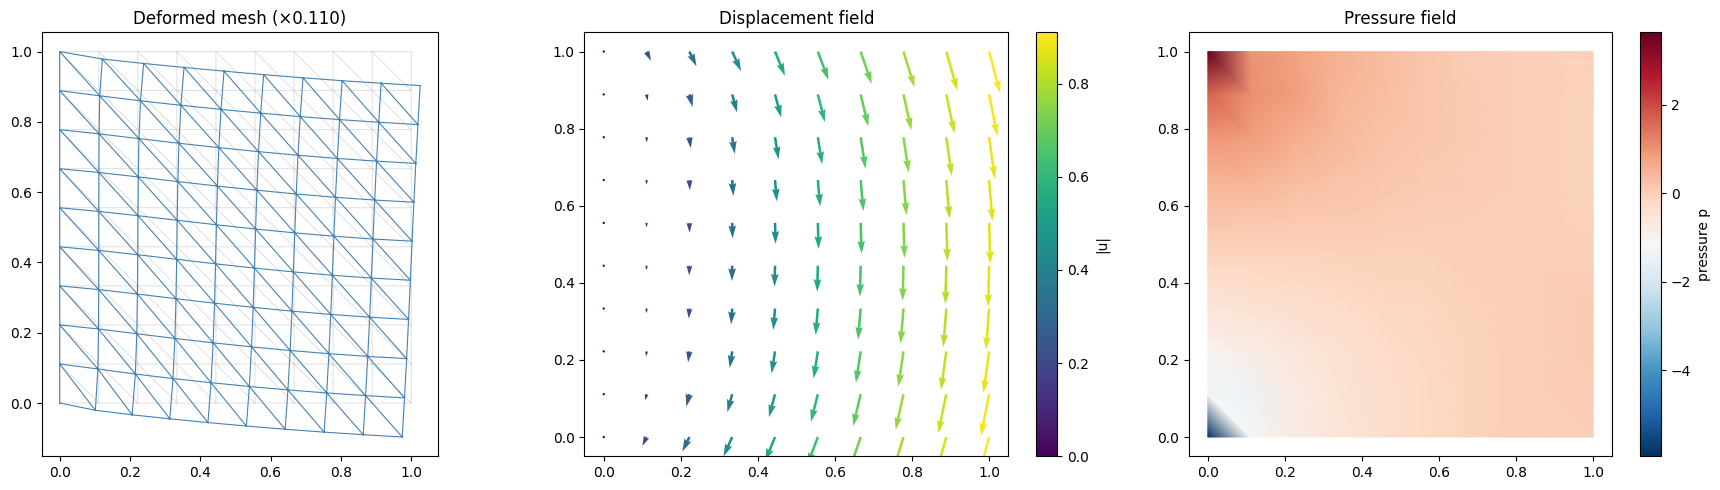

In [30]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

def plot_results(pts, tris, U, P, scale=None):
    Ux, Uy = U[0::2][:len(pts)], U[1::2][:len(pts)]   # corner dofs only (P1 part of the P2 field)

    if scale is None:
        domain_size = pts[:,0].max() - pts[:,0].min()
        max_disp = np.sqrt(Ux**2 + Uy**2).max()
        scale = 0.1 * domain_size / max_disp if max_disp > 0 else 1.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.triplot(mtri.Triangulation(pts[:,0], pts[:,1], tris), color='lightgray', lw=0.5)
    ax.triplot(mtri.Triangulation(pts[:,0]+scale*Ux, pts[:,1]+scale*Uy, tris), color='steelblue', lw=0.8)
    ax.set_title(f'Deformed mesh (×{scale:.3f})'); ax.set_aspect('equal')

    ax = axes[1]
    mag = np.sqrt(Ux**2 + Uy**2)
    q = ax.quiver(pts[:,0], pts[:,1], Ux, Uy, mag, cmap='viridis')
    plt.colorbar(q, ax=ax, label='|u|')
    ax.set_title('Displacement field'); ax.set_aspect('equal')

    ax = axes[2]
    tpc = ax.tripcolor(mtri.Triangulation(pts[:,0], pts[:,1], tris), P, shading='gouraud', cmap='RdBu_r')
    plt.colorbar(tpc, ax=ax, label='pressure p')
    ax.set_title('Pressure field'); ax.set_aspect('equal')

    plt.tight_layout(); plt.show()

plot_results(pts, tris, U, P)

In [31]:
def p_exact(pts, lam):
    x, y = pts[:,0], pts[:,1]
    return lam * np.pi * np.cos(np.pi*x) * (np.sin(np.pi*y) + np.cos(np.pi*y))

def compute_pressure_error(pts, tris, P, lam, qp, qw):
    Pe = p_exact(pts, lam)
    err = P - Pe
    coords = pts[tris]
    x1,y1 = coords[:,0,0], coords[:,0,1]
    x2,y2 = coords[:,1,0], coords[:,1,1]
    x3,y3 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    err2 = 0.0
    for (xi,eta), w in zip(qp, qw):
        phi = np.array([1-xi-eta, xi, eta])
        e_q = sum(phi[k]*err[tris[:,k]] for k in range(3))
        err2 += np.sum(areas*w*e_q**2)
    return np.sqrt(err2)

In [32]:
def compute_L2_error_p2(pts2, tris2, U, qp, qw):
    Ue = u_exact(pts2)
    err = U - Ue
    ex, ey = err[0::2], err[1::2]
    coords = pts2[tris2[:, :3]]
    x1,y1 = coords[:,0,0], coords[:,0,1]
    x2,y2 = coords[:,1,0], coords[:,1,1]
    x3,y3 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    err2 = 0.0
    for (xi,eta), w in zip(qp, qw):
        N = p2_shape_vals((1-xi-eta, xi, eta))
        ex_q = sum(N[k]*ex[tris2[:,k]] for k in range(6))
        ey_q = sum(N[k]*ey[tris2[:,k]] for k in range(6))
        err2 += np.sum(areas*w*(ex_q**2 + ey_q**2))
    return np.sqrt(err2)

In [33]:
from scipy.sparse.linalg import splu

def factor_mesh_for_schur(n, mu, qp, qw):
    pts, tris = build_mesh(n)
    pts2, tris2 = build_p2_mesh(pts, tris)
    _, A, B_mat, M, n_u, n_p = assemble_block_system_vectorized(pts, tris, pts2, tris2, mu, 1.0, qp, qw)

    tol = 1e-12
    is_bnd = (pts2[:,0]<tol)|(pts2[:,0]>1-tol)|(pts2[:,1]<tol)|(pts2[:,1]>1-tol)
    fixed_dofs = np.concatenate([2*np.where(is_bnd)[0], 2*np.where(is_bnd)[0]+1])

    A_bc = A.tolil(copy=True)
    for dof in fixed_dofs:
        A_bc.rows[dof] = [dof]; A_bc.data[dof] = [1.0]
    A_bc = A_bc.tocsr()

    B0 = B_mat.tolil(copy=True)
    B0[:, fixed_dofs] = 0.0    # used only in the elimination term, NOT in the pressure equation itself
    B0 = B0.tocsr()

    lu = splu(A_bc.tocsc())                 # factor ONCE per mesh — this is the expensive step you're now reusing
    Y = lu.solve(B0.T.toarray())            # n_u x n_p batched solve, reuses the factorization
    S0 = B_mat @ Y                          # lambda-independent part of the Schur complement — dense n_p x n_p

    return dict(pts2=pts2, tris2=tris2, A_bc=A_bc, B_mat=B_mat, B0=B0, M=M,
                lu=lu, S0=S0, n_u=n_u, n_p=n_p, fixed_dofs=fixed_dofs)

def solve_via_schur(mesh, lam, mu, qp, qw):
    pts2, tris2, lu = mesh['pts2'], mesh['tris2'], mesh['lu']
    fixed_dofs, B_mat, B0, M, S0 = mesh['fixed_dofs'], mesh['B_mat'], mesh['B0'], mesh['M'], mesh['S0']

    F_bc = assemble_load_vector_p2_vectorized(pts2, tris2, mu, lam, qp, qw)
    F_bc[fixed_dofs] = u_exact(pts2)[fixed_dofs]

    y = lu.solve(F_bc)                      # cheap — reuses cached factorization
    S = S0 + (1.0/lam) * M.toarray()        # tiny relative to the original system
    P = np.linalg.solve(S, B_mat @ y)
    U = lu.solve(F_bc - B0.T @ P)
    return U, P

In [34]:
n_t, lam_t = 16, 100
pts, tris = build_mesh(n_t); pts2, tris2 = build_p2_mesh(pts, tris)
K, A, B_mat, M, n_u, n_p = assemble_block_system_vectorized(pts, tris, pts2, tris2, mu, lam_t, qp, qw)
F_full = np.concatenate([assemble_load_vector_p2_vectorized(pts2, tris2, mu, lam_t, qp, qw), np.zeros(n_p)])
K_bc, F_bc = apply_dirichlet_block(K, F_full, pts2, n_u)
X = spsolve(K_bc, F_bc)
U_full, P_full = X[:n_u], X[n_u:]

mesh = factor_mesh_for_schur(n_t, mu, qp, qw)
U_s, P_s = solve_via_schur(mesh, lam_t, mu, qp, qw)
print("U match:", np.allclose(U_full, U_s, atol=1e-8))
print("P match:", np.allclose(P_full, P_s, atol=1e-6))

U match: True
P match: True


In [35]:
lambda_values = [1, 10, 100, 1000, 10000]
mesh_sizes = [4, 8, 16, 32]
mu = 1.0

errs_u = {lam: [] for lam in lambda_values}
errs_p = {lam: [] for lam in lambda_values}

for n in mesh_sizes:
    mesh = factor_mesh_for_schur(n, mu, qp, qw)   # A factored once per mesh size
    pts, tris = build_mesh(n)                      # cheap — needed for pressure error's P1 geometry
    for lam in lambda_values:
        U, P = solve_via_schur(mesh, lam, mu, qp, qw)
        errs_u[lam].append(compute_L2_error_p2(mesh['pts2'], mesh['tris2'], U, qp, qw))
        errs_p[lam].append(compute_pressure_error(pts, tris, P, lam, qp, qw))
    print(f"n={n} done")

h = 1.0 / (np.array(mesh_sizes) - 1)
rates_u = {lam: np.polyfit(np.log(h[-4:]), np.log(errs_u[lam][-4:]), 1)[0] for lam in lambda_values}
rates_p = {lam: np.polyfit(np.log(h[-4:]), np.log(errs_p[lam][-4:]), 1)[0] for lam in lambda_values}
for lam in lambda_values:
    print(f"lambda={lam:>6}: u-rate={rates_u[lam]:.2f}  p-rate={rates_p[lam]:.2f}")

n=4 done
n=8 done
n=16 done
n=32 done
lambda=     1: u-rate=3.90  p-rate=1.94
lambda=    10: u-rate=4.01  p-rate=1.95
lambda=   100: u-rate=4.01  p-rate=1.96
lambda=  1000: u-rate=4.00  p-rate=1.96
lambda= 10000: u-rate=4.00  p-rate=1.96


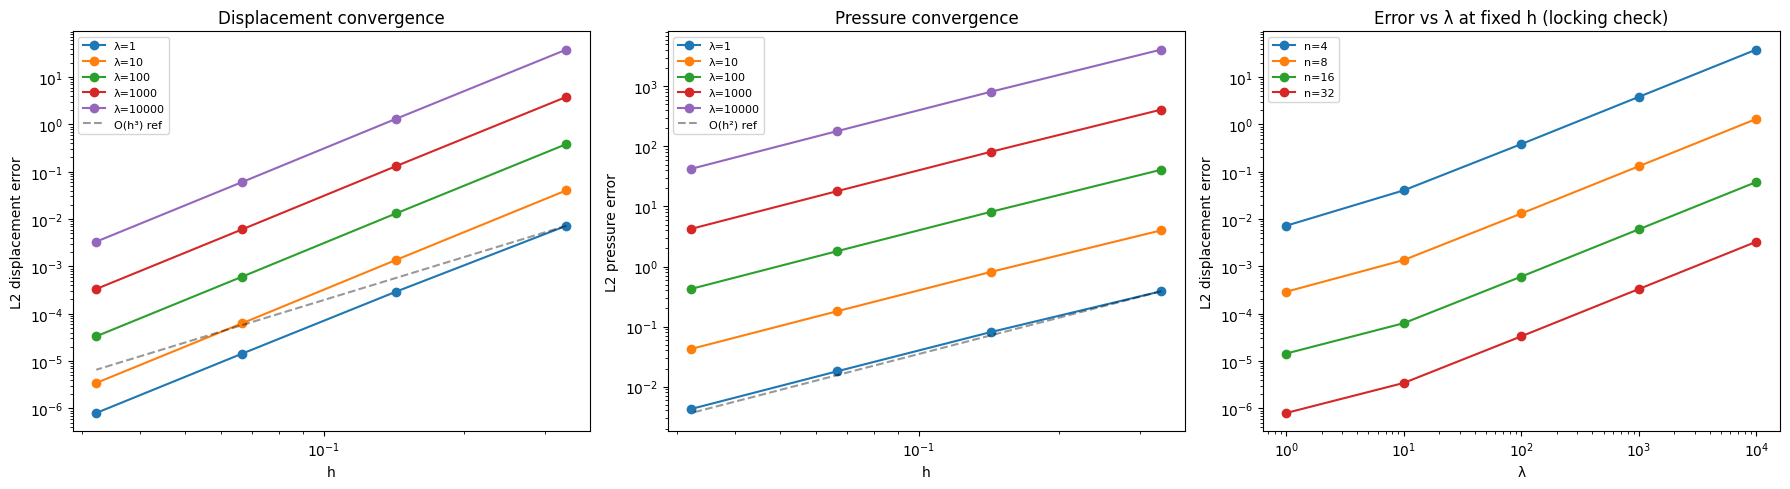

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: displacement L2 error vs h, log-log
ax = axes[0]
for lam in lambda_values:
    ax.loglog(h, errs_u[lam], 'o-', label=f'λ={lam}')
ax.loglog(h, errs_u[lambda_values[0]][0] * (h/h[0])**3, 'k--', alpha=0.4, label='O(h³) ref')
ax.set_xlabel('h'); ax.set_ylabel('L2 displacement error'); ax.legend(fontsize=8)
ax.set_title('Displacement convergence')

# Plot 2: pressure L2 error vs h, log-log
ax = axes[1]
for lam in lambda_values:
    ax.loglog(h, errs_p[lam], 'o-', label=f'λ={lam}')
ax.loglog(h, errs_p[lambda_values[0]][0] * (h/h[0])**2, 'k--', alpha=0.4, label='O(h²) ref')
ax.set_xlabel('h'); ax.set_ylabel('L2 pressure error'); ax.legend(fontsize=8)
ax.set_title('Pressure convergence')

# Plot 3: the locking diagnostic — error vs lambda, one line per FIXED mesh size
ax = axes[2]
errs_u_by_n = np.array([[errs_u[lam][i] for lam in lambda_values] for i in range(len(mesh_sizes))])
for i, n in enumerate(mesh_sizes):
    ax.loglog(lambda_values, errs_u_by_n[i], 'o-', label=f'n={n}')
ax.set_xlabel('λ'); ax.set_ylabel('L2 displacement error'); ax.legend(fontsize=8)
ax.set_title('Error vs λ at fixed h (locking check)')

plt.tight_layout(); plt.show()

In [37]:
ddec_n_fine = 128                        # fine "ground truth" mesh resolution

ddec_pts, ddec_tris = build_mesh(ddec_n_fine)
ddec_pts2, ddec_tris2 = build_p2_mesh(ddec_pts, ddec_tris)

# triangle-adjacency graph: two triangles are adjacent if they share an edge
ddec_edge_to_tris = {}
for t, tri in enumerate(ddec_tris):
    for a, b in [(tri[0],tri[1]), (tri[1],tri[2]), (tri[2],tri[0])]:
        key = (min(a,b), max(a,b))
        ddec_edge_to_tris.setdefault(key, []).append(t)

In [38]:
def assemble_body_force_p2_param(pts2, tris2, fx0, fy0, qp, qw):
    """Same pattern as assemble_body_force_vector_p2, but takes the load
    explicitly instead of going through the hardcoded body_force(x,y)."""
    n_tris, n_qp = len(tris2), len(qp)
    n_u = 2*len(pts2)
    coords = pts2[tris2[:, :3]]
    x1,y1 = coords[:,0,0], coords[:,0,1]
    x2,y2 = coords[:,1,0], coords[:,1,1]
    x3,y3 = coords[:,2,0], coords[:,2,1]
    areas = 0.5*np.abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
    L_arr = np.array([[1-xi-eta, xi, eta] for xi,eta in qp])
    w_arr = np.array(qw)
    L0, L1, L2 = L_arr[:,0], L_arr[:,1], L_arr[:,2]
    N_p2 = np.zeros((n_qp,6))
    N_p2[:,0]=L0*(2*L0-1); N_p2[:,1]=L1*(2*L1-1); N_p2[:,2]=L2*(2*L2-1)
    N_p2[:,3]=4*L1*L2; N_p2[:,4]=4*L2*L0; N_p2[:,5]=4*L0*L1
    weight = areas[:,None]*w_arr[None,:]
    int_N = np.einsum('tq,qi->ti', weight, N_p2)
    Floc = np.zeros((n_tris,12))
    Floc[:,0::2] = fx0*int_N; Floc[:,1::2] = fy0*int_N
    udofs = np.zeros((n_tris,12), dtype=int)
    udofs[:,0::2], udofs[:,1::2] = 2*tris2, 2*tris2+1
    F = np.zeros(n_u)
    np.add.at(F, udofs.ravel(), Floc.ravel())
    return F

ddec_mu, ddec_lam = 1.0, 1000.0     # matches your validated cantilever case (Cell 27)
ddec_load_cases = [(0.0,-1.0), (0.0,-2.0), (0.3,-1.0), (-0.3,-1.0)]

ddec_solves = []   # list of dicts: {'load':..., 'U':..., 'P':...}
for fx0, fy0 in ddec_load_cases:
    K, A, B_mat, M, n_u, n_p = assemble_block_system_vectorized(
        ddec_pts, ddec_tris, ddec_pts2, ddec_tris2, ddec_mu, ddec_lam, qp, qw)
    F_u = assemble_body_force_p2_param(ddec_pts2, ddec_tris2, fx0, fy0, qp, qw)
    F_full = np.concatenate([F_u, np.zeros(n_p)])
    K_bc, F_bc = apply_dirichlet_cantilever(K, F_full, ddec_pts2, n_u)
    X = spsolve(K_bc, F_bc)
    ddec_solves.append({'load': (fx0,fy0), 'U': X[:n_u], 'P': X[n_u:]})
    print(f"solved load=({fx0},{fy0})  max|U|={np.max(np.abs(X[:n_u])):.4f}")

solved load=(0.0,-1.0)  max|U|=0.8933
solved load=(0.0,-2.0)  max|U|=1.7866
solved load=(0.3,-1.0)  max|U|=0.8948
solved load=(-0.3,-1.0)  max|U|=0.8947


In [39]:
# Save fine mesh + DDEC training solves for elasticity_ddec.ipynb
loads_arr = np.array(ddec_load_cases)
U_all = np.stack([s['U'] for s in ddec_solves])
P_all = np.stack([s['P'] for s in ddec_solves])

np.savez('ddec_training_data.npz',
         ddec_pts=ddec_pts, ddec_tris=ddec_tris,
         ddec_mu=ddec_mu, ddec_lam=ddec_lam,
         loads=loads_arr, U_all=U_all, P_all=P_all)
print(f"saved {len(ddec_solves)} load cases to ddec_training_data.npz")

saved 4 load cases to ddec_training_data.npz
